In [1]:
# correlation
# price prediction 

# data combine 
# show correlation
# train linear regression on one year worth of data
# store linear regression model in flask
# predict estimated price based on that day's sentiment 
# display result 



In [2]:
#  data combine 

# get panel data first and add a date column for processing
import pandas as pd
from pandas_datareader import data
tickers = ['AAPL']

start_date = '2020-04-29'
end_date = '2021-10-10'

# User pandas_reader.data.DataReader to load data
panel_data = data.DataReader(tickers,'yahoo', start_date, end_date)
panel_data["date"] = panel_data.index
panel_data["date"] = pd.to_datetime(panel_data['date'])

# get reddit data 
reddit_data = pd.read_csv("./Reddit/cleaned_AAPL_sentiment.csv")
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.tz_localize(None)
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.date

# get twitter data
twitter_data = pd.read_csv("./Twitter/AAPL_cleaned_sentiment.csv")
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.tz_localize(None)
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.date

# get stocktwits data
stocktwits_data = pd.read_csv("./Stocktwits/AAPL_cleaned_sentiment.csv")
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.tz_localize(None)
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.date

# # get news data
# news_data = pd.read_csv("./news/cleaned_AAPL_sentiment.csv")
# news_data["date"] = pd.to_datetime(reddit_data['date'])



In [3]:
# add day names for each of the two df 
from datetime import date
import calendar
for index, row in reddit_data.iterrows():

    reddit_data.at[index,"day_name"] = calendar.day_name[row["date"].weekday()]
    
for index, row in twitter_data.iterrows():

    twitter_data.at[index,"day_name"] = calendar.day_name[row["date"].weekday()]
    
for index, row in stocktwits_data.iterrows():
  
    stocktwits_data.at[index,"day_name"] = calendar.day_name[row["date"].weekday()]

    
    
    
for index, row in panel_data.iterrows():
    date = pd.to_datetime(row["date"].values[0])
    panel_data.at[index,"day_name"]  = calendar.day_name[date.weekday()]

In [5]:
def transform_sentiment(df):
    for index, row in df.iterrows():
        if row['flair_sentiment'] == "NEGATIVE":
            df.at[index,"flair_score"] = 0 - row['flair_sentiment_score']
        if row['finbert_sentiment'] == "negative":
            df.at[index,"finbert_score"] = 0 - row['finbert_score']
        if row['finbert_sentiment'] == "neutral":
            df.at[index,"finbert_score"] = 0
    return df

reddit_data = transform_sentiment(reddit_data)
twitter_data = transform_sentiment(twitter_data)
stocktwits_data = transform_sentiment(stocktwits_data)

In [6]:
# groupby dates for panel data and sentiment data  
# note that weekends are missing for panel data
panel_groupby = panel_data.groupby(["date"]).mean()

In [7]:
reddit_groupby = reddit_data.groupby(["date"]).mean()
twitter_groupby = twitter_data.groupby(["date"]).mean()
stocktwits_groupby = stocktwits_data.groupby(["date"]).mean()

In [8]:
panel_data

Attributes,Adj Close,Close,High,Low,Open,Volume,date,day_name
Symbols,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,,
2020-04-28,68.888893,69.644997,71.457497,69.550003,71.269997,112004800.0,2020-04-28,Tuesday
2020-04-29,71.151558,71.932503,72.417503,70.972504,71.182503,137280800.0,2020-04-29,Wednesday
2020-04-30,72.652580,73.449997,73.632500,72.087502,72.489998,183064000.0,2020-04-30,Thursday
2020-05-01,71.482925,72.267502,74.750000,71.462502,71.562500,240616800.0,2020-05-01,Friday
2020-05-04,72.494316,73.290001,73.422501,71.580002,72.292503,133568000.0,2020-05-04,Monday
...,...,...,...,...,...,...,...,...
2021-10-04,139.139999,139.139999,142.210007,138.270004,141.759995,98322000.0,2021-10-04,Monday
2021-10-05,141.110001,141.110001,142.240005,139.360001,139.490005,80861100.0,2021-10-05,Tuesday


# correlation test 1 just weekdays drop weekends just apple reddit twitter and stocktwits

<AxesSubplot:>

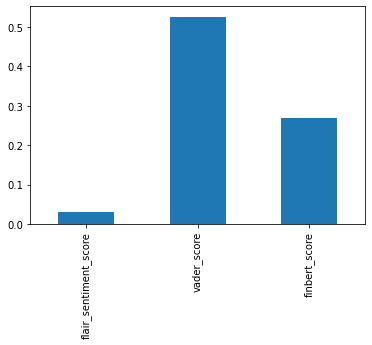

In [25]:
merge=pd.merge(reddit_groupby,panel_groupby, how='inner', left_index=True, right_index=True)
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].plot(kind="bar")

In [10]:
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

,flair_sentiment_score,vader_score,finbert_score
likes,-0.058197,0.256752,0.177642
flair_sentiment_score,1.000000,-0.113955,-0.120420
vader_score,-0.113955,1.000000,0.527519
finbert_score,-0.120420,0.527519,1.000000
flair_score,-0.596930,-0.029106,0.076695
"(Adj Close, AAPL)",0.029267,0.526453,0.271362
"(Close, AAPL)",0.029365,0.526025,0.270229
"(High, AAPL)",0.032432,0.526877,0.269091
"(Low, AAPL)",0.032180,0.523649,0.273129
"(Open, AAPL)",0.032911,0.524990,0.273926


<AxesSubplot:>

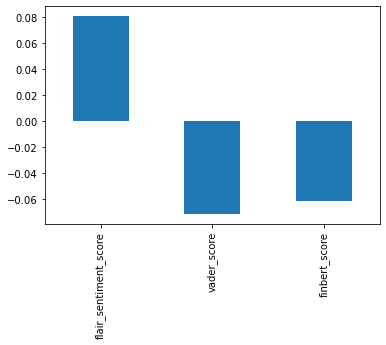

In [28]:
merge=pd.merge(twitter_groupby,panel_groupby, how='inner', left_index=True, right_index=True)
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[11].plot(kind="bar")

In [12]:
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

,flair_sentiment_score,vader_score,finbert_score
Unnamed: 0,-0.025902,-0.075183,0.038603
Unnamed: 0.1,-0.025902,-0.075183,0.038603
Number of Followers,-0.018029,0.039509,-0.083838
Number of Comments,0.030434,0.084601,0.015346
Number of Retweets,0.009572,0.075624,0.093738
Number of Likes,0.030818,0.088071,0.097413
flair_sentiment_score,1.000000,0.091087,-0.020340
vader_score,0.091087,1.000000,0.225244
finbert_score,-0.020340,0.225244,1.000000
flair_score,-0.740540,0.048192,0.024113


[]

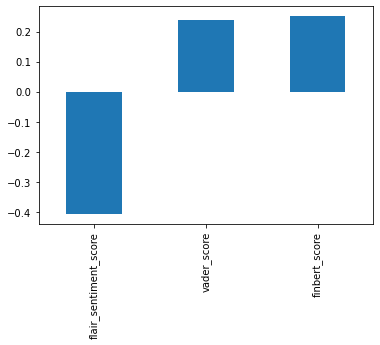

In [24]:
merge=pd.merge(stocktwits_groupby,panel_groupby, how='inner', left_index=True, right_index=True)
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[10].plot(kind="bar").plot(kind="bar")

In [14]:
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]]


# #  missing weekends - add weekend prices, leave it at friday 
# #  use the weighted sentiment 

# def weighted_weekends(data):
#     weighted_flair = weighted_vader = weighted_finbert = 0
#     new_df = []
#     for index, row in data.iterrows():
        
#         day = index.weekday()
#         if (day == 5): # saturday
#             weighted_flair += row['flair_sentiment_score'] * 0.2
#             weighted_vader += row['vader_score'] * 0.2
#             weighted_finbert += row['finbert_score'] * 0.2
#         elif (day == 6): # sunday
#             weighted_flair += row['flair_sentiment_score'] * 0.3
#             weighted_vader += row['vader_score'] * 0.3
#             weighted_finbert += row['finbert_score'] * 0.3
#         elif (day == 0): # monday
#             weighted_flair += row['flair_sentiment_score'] * 0.5
#             weighted_vader += row['vader_score'] * 0.5
#             weighted_finbert += row['finbert_score'] * 0.5
#             new_df.append([index, weighted_flair, weighted_vader, weighted_finbert])
#             weighted_flair = weighted_vader = weighted_finbert = 0
#         else:
#             new_df.append([index, row['flair_sentiment_score'], row['vader_score'], row['finbert_score']])
            
#     return new_df

,flair_sentiment_score,vader_score,finbert_score
Unnamed: 0,0.230256,0.006422,0.044401
person_id,-0.247945,0.016114,-0.028080
official,-0.265153,0.274761,0.192459
followers,-0.249652,0.503609,0.274674
likes,-0.247555,0.482212,0.351035
flair_sentiment_score,1.000000,-0.436063,-0.508918
vader_score,-0.436063,1.000000,0.689050
finbert_score,-0.508918,0.689050,1.000000
flair_score,-0.890389,0.481398,0.526050
"(Adj Close, AAPL)",-0.404536,0.234532,0.244865


# correlation test 2 just weekdays drop weekends all stocks

In [ ]:
#  data combine 

# get panel data first and add a date column for processing
import pandas as pd
from pandas_datareader import data
tickers = ['AAPL']

start_date = '2020-04-29'
end_date = '2021-10-10'

# User pandas_reader.data.DataReader to load data
panel_data = data.DataReader(tickers,'yahoo', start_date, end_date)
panel_data["date"] = panel_data.index
panel_data["date"] = pd.to_datetime(panel_data['date'])

# get reddit data 
reddit_data = pd.read_csv("reddit_combined.csv")
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.tz_localize(None)
reddit_data["date"] = pd.to_datetime(reddit_data['date']).dt.date

# get twitter data
twitter_data = pd.read_csv("twitter_combined.csv")
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.tz_localize(None)
twitter_data["date"] = pd.to_datetime(twitter_data['Datetime']).dt.date

# get stocktwits data
stocktwits_data = pd.read_csv("stocktwits_combined.csv")
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.tz_localize(None)
stocktwits_data["date"] = pd.to_datetime(stocktwits_data['date_created']).dt.date

# # get news data
# news_data = pd.read_csv("./news/cleaned_AAPL_sentiment.csv")
# news_data["date"] = pd.to_datetime(reddit_data['date'])

 

In [ ]:

def transform_sentiment(df):
    for index, row in df.iterrows():
        if row['flair_sentiment'] == "NEGATIVE":
            df.at[index,"flair_score"] = 0 - row['flair_sentiment_score']
        if row['finbert_sentiment'] == "negative":
            df.at[index,"finbert_score"] = 0 - row['finbert_score']
        if row['finbert_sentiment'] == "neutral":
            df.at[index,"finbert_score"] = 0
    return df

reddit_data = transform_sentiment(reddit_data)
twitter_data = transform_sentiment(twitter_data)
stocktwits_data = transform_sentiment(stocktwits_data)

panel_groupby = panel_data.groupby(["date"]).mean()
reddit_groupby = reddit_data.groupby(["date"]).mean()
twitter_groupby = twitter_data.groupby(["date"]).mean()
stocktwits_groupby = stocktwits_data.groupby(["date"]).mean()

In [ ]:
merge=pd.merge(reddit_groupby,panel_groupby, how='inner', left_index=True, right_index=True)
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].plot(kind="bar")
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

In [ ]:
merge=pd.merge(twitter_groupby,panel_groupby, how='inner', left_index=True, right_index=True)
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].plot(kind="bar")
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]]

In [ ]:
merge=pd.merge(stocktwits_groupby,panel_groupby, how='inner', left_index=True, right_index=True)
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]].iloc[6].plot(kind="bar")
merge.corr()[["flair_sentiment_score","vader_score","finbert_score"]]